In [ ]:
# kmeans weighted by deformation-gradient 
# reclustering triggered by variance of deformation-gradiet
# separate hte lattice into 2 subregions. each subregion is piecewise smooth but the F jumps across their interface.  

from shared_2D import *

# problem specification
NX, NY = 49, 50
LATTICE_SPACING = 2**(1/6)
BORDER_LAYERS = 3
CUTOFF_FACTOR = 1.9
MAX_ITER = 10000
LOG_EVERY = 100
PINN_HISTORY_JSON_FILENAME = "pinn-history-2d-piecewise/pinn-history-2d-piecewise-reclusterDEFGRAD.json"
MIN_EPOCHS_BEFORE_RECLUSTER = 1000
RECLUSTER_EVERY = 500
DEFGRAD_TRIGGER_TOL = 1.0e-3
DEFGRAD_JUMP_TOL = 5.0e-3
DEFGRAD_JUMP_MAD_FACTOR = 3.0
MIN_SPLIT_CLUSTER_SIZE = 10
MIN_DISCONTINUITY_EDGES = 3


In [6]:

def make_piecewise_deformed_positions(
    reference_pos,
    interface_x,
    F_left,
    F_right,
):
    """
    Construct a continuous piecewise-affine deformation separated by
    the vertical interface x = interface_x.

    For continuity along the entire interface, F_left and F_right must
    have the same second column.
    """
    reference_pos = np.asarray(reference_pos, dtype=np.float64)

    interface_point = np.array(
        [interface_x, 0.0],
        dtype=np.float64,
    )

    left = reference_pos[:, 0] <= interface_x
    right = ~left

    current_pos = np.empty_like(reference_pos)

    current_pos[left] = reference_pos[left] @ F_left.T

    translation = (
        F_left @ interface_point
        - F_right @ interface_point
    )

    current_pos[right] = (
        reference_pos[right] @ F_right.T
        + translation
    )

    return current_pos
atom_pos = make_triangular_lattice(NX,NY,LATTICE_SPACING)

INTERFACE_X = 0.5 * (
    atom_pos[:, 0].min() + atom_pos[:, 0].max()
)

F_LEFT = np.array([
    [1.02, 0.02],
    [0.00, 0.99],
])

F_RIGHT = np.array([
    [1.08, 0.02],
    [0.00, 0.99],
])

piecewise_pos = make_piecewise_deformed_positions(reference_pos=atom_pos,interface_x=INTERFACE_X,F_left=F_LEFT,F_right=F_RIGHT,)


# 3 layers of atoms bordering the square are flagged as atomistic-region
atomistic_indices,continuum_indices = split_atomistic_continuum(NX,NY,BORDER_LAYERS)
continuum_atom_pos = atom_pos[continuum_indices]
atomistic_atom_pos = atom_pos[atomistic_indices]

# manually pick 5 rep_atoms among the continuum atoms 
initial_rep_indices, rep_targets = pick_manual_rep_atoms(atom_pos,continuum_indices,0.1)

neighs = build_first_neighbor_list(atom_pos, spacing=LATTICE_SPACING)

neighbor_counts = np.array([len(nbrs) for nbrs in neighs])
print("neighbor counts:", np.unique(neighbor_counts, return_counts=True))
print("max neighbors:", neighbor_counts.max())

# compute deformation-gradient. this is approx 0 because we havent done any deformation yet
initial_importance = np.ones(len(continuum_indices))
# assign continuum-atoms to their clusters, and equilibrate over 100 iterations of kmeans 
cluster_idx, centers, rep_indices, cac_weights, history = kmeans_weighted(
    atom_pos=atom_pos,
    continuum_indices=continuum_indices,
    initial_rep_indices=initial_rep_indices, 
    importance_weights=initial_importance
    )

print("number of atoms \t\t", len(atom_pos))
print("atomistic atoms \t\t", len(atomistic_indices))
print("continuum atoms \t\t", len(continuum_indices))
print("initial rep atom indices \t", initial_rep_indices)
print("final rep atom indices \t\t", rep_indices)
print("cac_weights \t\t\t", cac_weights)
print("sum of cac_weights \t\t\t", cac_weights.sum())


did_recluster, recluster_info = (
    recluster_deformation_gradient_weighted(
        atom_pos_ref=atom_pos,
        current_pos_np=piecewise_pos,
        continuum_indices=continuum_indices,
        cluster_idx=cluster_idx,
        rep_indices=rep_indices,
        cac_weights=cac_weights,
        neighs=neighs,
        trigger_tol=DEFGRAD_TRIGGER_TOL,
        jump_tol=DEFGRAD_JUMP_TOL,
        jump_mad_factor=DEFGRAD_JUMP_MAD_FACTOR,
        min_split_cluster_size=MIN_SPLIT_CLUSTER_SIZE,
        min_cut_edges=MIN_DISCONTINUITY_EDGES,
        max_iter=100,
        tol=1e-10,
    )
)

print("did recluster:", did_recluster)
print(
    "quadrature triggered:",
    recluster_info["quadrature_triggered"],
)
print(
    "discontinuity triggered:",
    recluster_info["discontinuity_triggered"],
)

if did_recluster:
    cluster_idx = recluster_info["cluster_idx"]
    centers = recluster_info["centers"]
    rep_indices = recluster_info["rep_indices"]
    cac_weights = recluster_info["cac_weights"]

    print("split information:")
    for split in recluster_info["split_info"]["splits"]:
        print(split)

    print(
        "number of clusters:",
        recluster_info["split_info"]["num_clusters_before"],
        "->",
        recluster_info["split_info"]["num_clusters_after"],
    )

neighbor counts: (array([2, 3, 4, 5, 6]), array([   2,   50,   94,   48, 2256]))
max neighbors: 6
number of atoms 		 2450
atomistic atoms 		 558
continuum atoms 		 1892
initial rep atom indices 	 [1200  350  384 2065 2099]
final rep atom indices 		 [1200  600  624 1825 1849]
cac_weights 			 [302. 396. 396. 398. 400.]
sum of cac_weights 			 1892.0
did recluster: True
quadrature triggered: True
discontinuity triggered: True
split information:
{'old_cluster': 0, 'old_size': 293, 'new_sizes': [203, 90], 'jump_threshold': 0.005, 'max_jump': 0.03499999999999992, 'num_cut_edges': 142}
number of clusters: 5 -> 6


# the below plot looks good 
- this is just after one iteration of reclustering. 

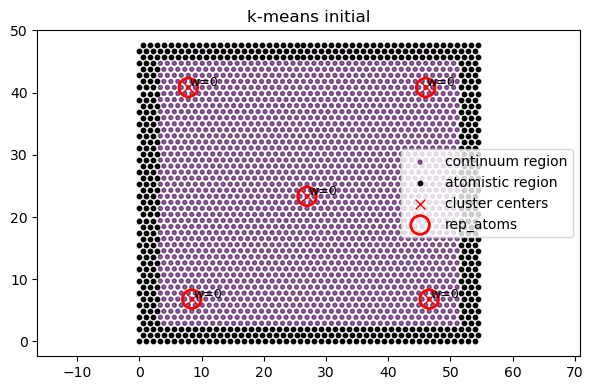

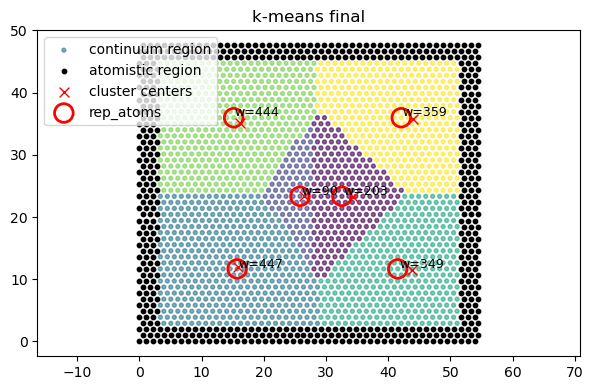

In [7]:
plot_partition(atom_pos, atomistic_indices, continuum_indices, [0]*len(continuum_indices), initial_rep_indices, atom_pos[initial_rep_indices],[0 for i in range(initial_rep_indices.size)], figure_size=(6,4),plot_title="k-means initial")
plot_partition(atom_pos, atomistic_indices, continuum_indices, cluster_idx, rep_indices, centers,cac_weights, figure_size=(6,4),plot_title="k-means final")

# now redo the whole `kmeans_weighted` on the above 6-point lattice

In [3]:
F_full, q_defgrad_full, valid_full = local_deformation_gradient(reference_pos=atom_pos,current_pos=atom_pos,neighs=neighs,)
q_continuum = q_defgrad_full[continuum_indices] # this is just an array of 1's


In [4]:
cluster_idx, centers, rep_indices, cac_weights, history = kmeans_weighted(
    atom_pos=atom_pos,
    continuum_indices=continuum_indices,
    initial_rep_indices=rep_indices, 
    importance_weights=q_continuum
    )

# the below plot looks wrong 
- the `kmean_weighted` does not know that there's an interface there.
- a `rep-atom` in one subregion should not grab a `continuum-atom` from the other subregion

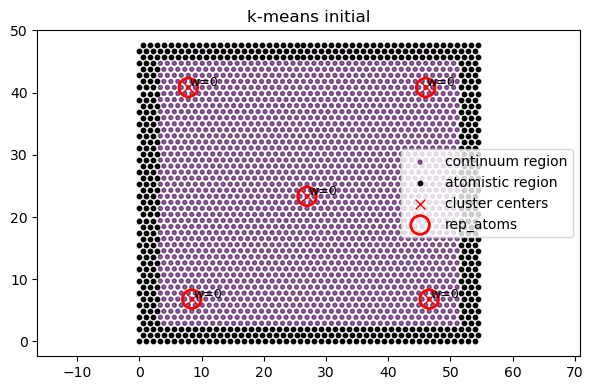

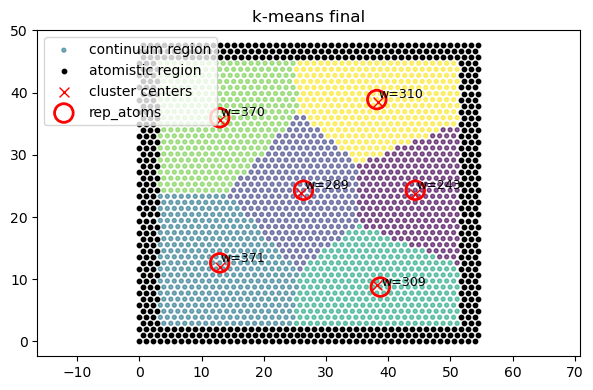

In [5]:
plot_partition(atom_pos, atomistic_indices, continuum_indices, [0]*len(continuum_indices), initial_rep_indices, atom_pos[initial_rep_indices],[0 for i in range(initial_rep_indices.size)], figure_size=(6,4),plot_title="k-means initial")
plot_partition(atom_pos, atomistic_indices, continuum_indices, cluster_idx, rep_indices, centers,cac_weights, figure_size=(6,4),plot_title="k-means final")

In [4]:
import json

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import Normalize


def load_pinn_history(json_filename):
    with open(json_filename, "r") as f:
        return json.load(f)


def animate_pinn_history_gif(
    json_filename,
    output_gif="pinn_relaxation.gif",
    fps=10,
    atom_size=12,
    rep_size=120,
    percentile_limits=(1.0, 99.0),
):
    history = load_pinn_history(json_filename)

    if len(history) == 0:
        raise ValueError("JSON history is empty.")

    missing_q = [
        frame_id
        for frame_id, entry in enumerate(history)
        if "q_full" not in entry
    ]

    if missing_q:
        raise KeyError(
            f"q_full is missing from {len(missing_q)} frame(s). "
            f"First missing frame: {missing_q[0]}"
        )

    all_pos = np.asarray(
        [entry["pos"] for entry in history],
        dtype=np.float64,
    )

    all_q = np.asarray(
        [entry["q_full"] for entry in history],
        dtype=np.float64,
    )

    if all_pos.ndim != 3 or all_pos.shape[2] != 2:
        raise ValueError(
            "Position history must have shape "
            "(n_frames, n_atoms, 2)."
        )

    n_frames, n_atoms, _ = all_pos.shape

    if all_q.shape != (n_frames, n_atoms):
        raise ValueError(
            "q_full history must have shape "
            f"({n_frames}, {n_atoms}), "
            f"but received {all_q.shape}."
        )

    finite_q = all_q[np.isfinite(all_q)]

    if finite_q.size == 0:
        raise ValueError("q_full contains no finite values.")

    lower_percentile, upper_percentile = percentile_limits

    q_min = np.percentile(finite_q, lower_percentile)
    q_max = np.percentile(finite_q, upper_percentile)

    # Avoid a degenerate color scale when q is initially constant.
    if np.isclose(q_min, q_max):
        q_center = q_min
        q_padding = max(abs(q_center) * 1.0e-6, 1.0e-12)
        q_min = q_center - q_padding
        q_max = q_center + q_padding

    color_norm = Normalize(vmin=q_min, vmax=q_max)

    x_min = np.nanmin(all_pos[:, :, 0])
    x_max = np.nanmax(all_pos[:, :, 0])
    y_min = np.nanmin(all_pos[:, :, 1])
    y_max = np.nanmax(all_pos[:, :, 1])

    x_range = x_max - x_min
    y_range = y_max - y_min

    pad_x = 0.05 * x_range if x_range > 0.0 else 1.0
    pad_y = 0.05 * y_range if y_range > 0.0 else 1.0

    fig, ax = plt.subplots(figsize=(9, 7))

    pos0 = all_pos[0]
    q0 = all_q[0]

    atoms_scatter = ax.scatter(
        pos0[:, 0],
        pos0[:, 1],
        c=q0,
        s=atom_size,
        cmap="viridis",
        norm=color_norm,
        edgecolors="none",
    )

    rep_indices0 = np.asarray(
        history[0].get("rep_indices", []),
        dtype=int,
    )

    rep_pos0 = (
        pos0[rep_indices0]
        if len(rep_indices0) > 0
        else np.empty((0, 2))
    )

    reps_scatter = ax.scatter(
        rep_pos0[:, 0],
        rep_pos0[:, 1],
        s=rep_size,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        label="Representative atoms",
    )

    colorbar = fig.colorbar(
        atoms_scatter,
        ax=ax,
        pad=0.02,
    )
    colorbar.set_label(r"$q_i=\|\mathbf{F}_i-\mathbf{I}\|_F$")

    title = ax.set_title("")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)
    ax.legend(loc="upper right")

    def update(frame_id):
        entry = history[frame_id]

        pos = all_pos[frame_id]
        q_full = all_q[frame_id]

        atoms_scatter.set_offsets(pos)
        atoms_scatter.set_array(q_full)

        rep_indices = np.asarray(
            entry.get("rep_indices", []),
            dtype=int,
        )

        if len(rep_indices) > 0:
            reps_scatter.set_offsets(pos[rep_indices])
        else:
            reps_scatter.set_offsets(np.empty((0, 2)))

        epoch = int(entry["epoch"])
        loss_energy = float(entry["loss_energy"])
        true_energy = entry.get("true_energy")

        title_text = (
            "PINN 2D deformation-gradient re-clustering\n"
            f"epoch={epoch}, loss={loss_energy:.6e}"
        )

        if true_energy is not None:
            title_text += (
                f", true energy={float(true_energy):.6e}"
            )

        title_text += (
            f"\nrepresentative atoms={len(rep_indices)}, "
            f"q max={np.nanmax(q_full):.3e}"
        )

        title.set_text(title_text)

        return atoms_scatter, reps_scatter, title

    animation = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=1000.0 / fps,
        blit=False,
    )

    animation.save(
        output_gif,
        writer=PillowWriter(fps=fps),
        dpi=120,
    )

    plt.close(fig)
    print(f"Saved GIF to: {output_gif}")

In [11]:
animate_pinn_history_gif(
    json_filename=PINN_HISTORY_JSON_FILENAME,
    output_gif="figs/pinn_2d_piecewise_recluster_defgrad.gif",
    fps=2)

Saved GIF to: figs/pinn_2d_piecewise_recluster_defgrad.gif


## Color by q_full or by DetF

In [13]:
import json

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm


def load_pinn_history(json_filename):
    with open(json_filename, "r") as f:
        return json.load(f)


def animate_pinn_history_gif(
    json_filename,
    output_gif="pinn_relaxation.gif",
    fps=10,
    color_by="q_full",
    atom_size=12,
    rep_size=120,
    percentile_limits=(1.0, 99.0),
):
    """
    Animate PINN history.

    color_by options:
        "q_full"    : color atoms by q_i = ||F_i - I||
        "detF"      : color atoms by det(F_i)
        "material"  : color atoms by atom/material type
    """
    history = load_pinn_history(json_filename)

    if len(history) == 0:
        raise ValueError("JSON history is empty.")

    all_pos = np.asarray(
        [entry["pos"] for entry in history],
        dtype=np.float64,
    )

    if all_pos.ndim != 3 or all_pos.shape[2] != 2:
        raise ValueError(
            "Position history must have shape "
            "(n_frames, n_atoms, 2)."
        )

    n_frames, n_atoms, _ = all_pos.shape

    if color_by == "q_full":
        if "q_full" not in history[0]:
            raise KeyError("History does not contain q_full.")

        all_color = np.asarray(
            [entry["q_full"] for entry in history],
            dtype=np.float64,
        )

        color_label = r"$q_i=\|\mathbf{F}_i-\mathbf{I}\|_F$"
        cmap = "viridis"
        discrete = False

    elif color_by == "detF":
        if "detF" not in history[0]:
            raise KeyError("History does not contain detF.")

        all_color = np.asarray(
            [entry["detF"] for entry in history],
            dtype=np.float64,
        )

        color_label = r"$\det(\mathbf{F}_i)$"
        cmap = "coolwarm"
        discrete = False

    elif color_by in ("material", "atom_type", "atom-type"):
        key = None

        for candidate in ("material", "atom_type", "atom-type"):
            if candidate in history[0]:
                key = candidate
                break

        if key is None:
            raise KeyError(
                "History does not contain material, atom_type, "
                "or atom-type."
            )

        material0 = np.asarray(
            history[0][key],
            dtype=int,
        )

        if material0.shape != (n_atoms,):
            raise ValueError(
                f"{key} must have shape ({n_atoms},)."
            )

        all_color = np.repeat(
            material0[None, :],
            n_frames,
            axis=0,
        )

        color_label = "Atom type"
        cmap = ListedColormap(
            [
                "tab:blue",
                "tab:orange",
                "tab:green",
                "tab:red",
                "tab:purple",
                "tab:brown",
            ]
        )
        discrete = True

    else:
        raise ValueError(
            "color_by must be one of: q_full, detF, material"
        )

    if all_color.shape != (n_frames, n_atoms):
        raise ValueError(
            f"{color_by} history must have shape "
            f"({n_frames}, {n_atoms}), "
            f"but received {all_color.shape}."
        )

    x_min = np.nanmin(all_pos[:, :, 0])
    x_max = np.nanmax(all_pos[:, :, 0])
    y_min = np.nanmin(all_pos[:, :, 1])
    y_max = np.nanmax(all_pos[:, :, 1])

    x_range = x_max - x_min
    y_range = y_max - y_min

    pad_x = 0.05 * x_range if x_range > 0.0 else 1.0
    pad_y = 0.05 * y_range if y_range > 0.0 else 1.0

    if discrete:
        material_values = np.unique(all_color[0].astype(int))
        vmin = material_values.min() - 0.5
        vmax = material_values.max() + 0.5

        boundaries = np.arange(
            material_values.min() - 0.5,
            material_values.max() + 1.5,
            1.0,
        )

        color_norm = BoundaryNorm(
            boundaries,
            cmap.N,
        )

        color_ticks = material_values

    else:
        finite_values = all_color[np.isfinite(all_color)]

        if finite_values.size == 0:
            raise ValueError(
                f"{color_by} contains no finite values."
            )

        lower_percentile, upper_percentile = percentile_limits

        vmin = np.percentile(
            finite_values,
            lower_percentile,
        )
        vmax = np.percentile(
            finite_values,
            upper_percentile,
        )

        if np.isclose(vmin, vmax):
            center = vmin
            padding = max(
                abs(center) * 1.0e-6,
                1.0e-12,
            )
            vmin = center - padding
            vmax = center + padding

        color_norm = Normalize(
            vmin=vmin,
            vmax=vmax,
        )

        color_ticks = None

    fig, ax = plt.subplots(figsize=(9, 7))

    pos0 = all_pos[0]
    color0 = all_color[0]

    atoms_scatter = ax.scatter(
        pos0[:, 0],
        pos0[:, 1],
        c=color0,
        s=atom_size,
        cmap=cmap,
        norm=color_norm,
        edgecolors="none",
    )

    rep_indices0 = np.asarray(
        history[0].get("rep_indices", []),
        dtype=int,
    )

    rep_pos0 = (
        pos0[rep_indices0]
        if len(rep_indices0) > 0
        else np.empty((0, 2))
    )

    reps_scatter = ax.scatter(
        rep_pos0[:, 0],
        rep_pos0[:, 1],
        s=rep_size,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        label="Representative atoms",
    )

    colorbar = fig.colorbar(
        atoms_scatter,
        ax=ax,
        pad=0.02,
        ticks=color_ticks,
    )

    colorbar.set_label(color_label)

    title = ax.set_title("")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)

    if len(rep_indices0) > 0:
        ax.legend(loc="upper right")

    def update(frame_id):
        entry = history[frame_id]

        pos = all_pos[frame_id]
        color_values = all_color[frame_id]

        atoms_scatter.set_offsets(pos)
        atoms_scatter.set_array(color_values)

        rep_indices = np.asarray(
            entry.get("rep_indices", []),
            dtype=int,
        )

        if len(rep_indices) > 0:
            reps_scatter.set_offsets(pos[rep_indices])
        else:
            reps_scatter.set_offsets(np.empty((0, 2)))

        epoch = int(entry["epoch"])
        loss_energy = float(entry["loss_energy"])
        true_energy = entry.get("true_energy")

        title_text = (
            "PINN 2D history\n"
            f"color={color_by}, epoch={epoch}, "
            f"loss={loss_energy:.6e}"
        )

        if true_energy is not None:
            title_text += (
                f", true energy={float(true_energy):.6e}"
            )

        if len(rep_indices) > 0:
            title_text += (
                f"\nrepresentative atoms={len(rep_indices)}"
            )

        if color_by == "detF":
            title_text += (
                f", detF mean={np.nanmean(color_values):.4f}"
            )
        elif color_by == "q_full":
            title_text += (
                f", q max={np.nanmax(color_values):.3e}"
            )

        title.set_text(title_text)

        return atoms_scatter, reps_scatter, title

    animation = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=1000.0 / fps,
        blit=False,
    )

    animation.save(
        output_gif,
        writer=PillowWriter(fps=fps),
        dpi=120,
    )

    plt.close(fig)
    print(f"Saved GIF to: {output_gif}")

In [ ]:
animate_pinn_history_gif(
    json_filename="pinn-history-2d-piecewise/pinn-history-2d-piecewise-neumann.json",
    output_gif="2d_alloy_neumann_qfull.gif",
    color_by="q_full",
)

animate_pinn_history_gif(
    json_filename="pinn-history-2d-piecewise/pinn-history-2d-piecewise-neumann.json",
    output_gif="2d_alloy_neumann_detF.gif",
    color_by="detF",
)

animate_pinn_history_gif(
    json_filename="pinn-history-2d-piecewise/pinn-history-2d-piecewise-neumann.json",
    output_gif="2d_alloy_neumann_material.gif",
    color_by="material",
)

Saved GIF to: two_material_q.gif
Saved GIF to: two_material_detF.gif
Saved GIF to: two_material_material.gif


![](two_material_q.gif)

![](two_material_detF.gif)

![](two_material_material.gif)